In [7]:
import sys,os
sys.path.append(os.path.abspath('..'))

from src.data import get_data
from src.baseline import seasonal_naive_model, lightgbm_model

In [3]:
df = get_data('df_final')
df.head()

Đã đọc thành công dữ liệu từ: C:\Users\YOGA\Desktop\01_Time Series\PROJECT\Github\Electricity-Load-Diagrams\data\processed\df_final


,total_load,hour,day_of_week,quarter,month,day_of_month,day_of_year,week_of_year,is_weekend,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,year_sin,year_cos,holiday_name
Timestamp,,,,,,,,,,,,,,,,,,
2012-01-01 00:00:00,104230.493821,0,6,1,1,1,1,52,1,0.000000,1.000000,-0.781831,0.62349,0.0,1.0,0.0,1.0,Ano Novo
2012-01-01 01:00:00,112550.368868,1,6,1,1,1,1,52,1,0.258819,0.965926,-0.781831,0.62349,0.0,1.0,0.0,1.0,Ano Novo
2012-01-01 02:00:00,110930.247627,2,6,1,1,1,1,52,1,0.500000,0.866025,-0.781831,0.62349,0.0,1.0,0.0,1.0,Ano Novo
2012-01-01 03:00:00,106191.754971,3,6,1,1,1,1,52,1,0.707107,0.707107,-0.781831,0.62349,0.0,1.0,0.0,1.0,Ano Novo
2012-01-01 04:00:00,103540.419166,4,6,1,1,1,1,52,1,0.866025,0.500000,-0.781831,0.62349,0.0,1.0,0.0,1.0,Ano Novo


In [8]:
target = 'total_load'
features = [col for col in df.columns if col != target]

In [14]:
val, metrics = seasonal_naive_model(df, target, 24 * 365)

print("KẾT QUẢ NAIVE BASELINE (Dựa trên Lag 1 tuần)")
print("-" * 40)
print(f"MAE  : {metrics['MAE']:,.2f} kWh")
print(f"RMSE : {metrics['RMSE']:,.2f} kWh")
print(f"MAPE : {metrics['MAPE']:.2f} %")

KẾT QUẢ NAIVE BASELINE (Dựa trên Lag 1 tuần)
----------------------------------------
MAE  : 14,597.06 kWh
RMSE : 21,625.73 kWh
MAPE : 6.07 %


In [16]:
val, model, metrics = lightgbm_model(df, target, features)

print("KẾT QUẢ LIGHTGBM MODEL")
print("-" * 40)
print(f"MAE  : {metrics['MAE']:,.2f} kWh")
print(f"RMSE : {metrics['RMSE']:,.2f} kWh")
print(f"MAPE : {metrics['MAPE']:.2f} %")

KẾT QUẢ LIGHTGBM MODEL
----------------------------------------
MAE  : 13,747.55 kWh
RMSE : 19,949.07 kWh
MAPE : 5.90 %


<Figure size 1000x800 with 0 Axes>

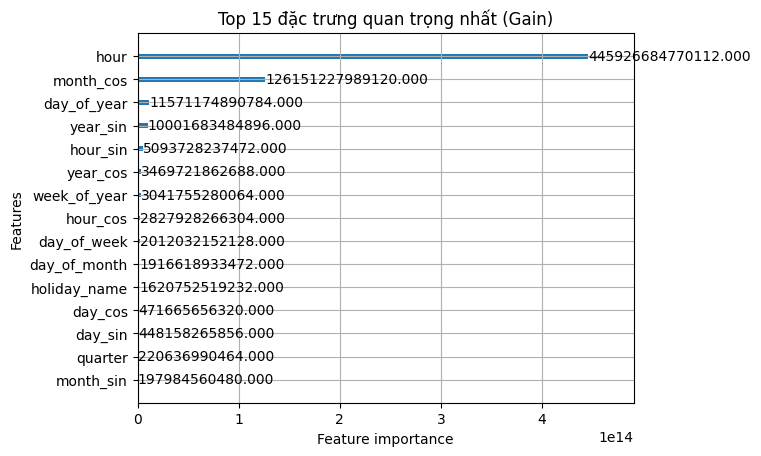

In [17]:
import matplotlib.pyplot as plt
import lightgbm as lgb

# Vẽ biểu đồ tầm quan trọng của các biến
plt.figure(figsize=(10, 8))
lgb.plot_importance(model, max_num_features=15, importance_type='gain')
plt.title('Top 15 đặc trưng quan trọng nhất (Gain)')
plt.show()